In [1]:
!pip -q install rdkit torch-geometric tqdm scikit-learn requests matplotlib chembl_webresource_client

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.6 MB/s eta 0:00:00


In [2]:
import torch

pt_version = torch.__version__.split('+')[0]

if torch.version.cuda is not None:
    device_version = 'cu' + torch.version.cuda.replace('.', '')
else:
    device_version = 'cpu'

print(f"PyTorch 버전: {pt_version}, 환경: {device_version}")

!pip install torch_geometric
!pip install pyg_lib torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-{pt_version}+{device_version}.html

PyTorch 버전: 2.10.0, 환경: cu128
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 86.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 94.5 MB/s eta 0:00:00


In [3]:
import os
import time
import random
import requests
import numpy as np
import pandas as pd

from urllib.parse import quote
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import roc_auc_score, average_precision_score

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

from torch_geometric.data import HeteroData
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import HANConv

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

DEVICE: cuda


In [4]:
# -----------------------------
# Toy Data Loading
# Transductive notebook에서 쓰던 toy data를 inductive 코드에 그대로 사용
# -----------------------------

import pandas as pd

# 1) Yeast gene → metabolite
gene_metabolite_edges = pd.DataFrame([
    # Early mevalonate pathway
    ["ERG10", "acetoacetyl-CoA"],
    ["ERG13", "3-hydroxy-3-methylglutaryl-CoA"],
    ["HMG1",  "mevalonic acid"],
    ["HMG2",  "mevalonic acid"],
    ["ERG12", "mevalonate 5-phosphate"],
    ["ERG8",  "mevalonate 5-diphosphate"],
    ["ERG19", "isopentenyl pyrophosphate"],

    # Isoprenoid intermediates
    ["IDI1",  "dimethylallyl pyrophosphate"],
    ["IDI1",  "isopentenyl pyrophosphate"],
    ["ERG20", "geranyl pyrophosphate"],
    ["ERG20", "farnesyl pyrophosphate"],
    ["BTS1",  "geranylgeranyl pyrophosphate"],

    # Sterol biosynthesis
    ["ERG9",  "squalene"],
    ["ERG1",  "2,3-oxidosqualene"],
    ["ERG7",  "lanosterol"],
    ["ERG11", "lanosterol"],
    ["ERG24", "zymosterol"],
    ["ERG6",  "fecosterol"],
    ["ERG2",  "episterol"],
    ["ERG3",  "ergosterol"],
    ["ERG5",  "ergosterol"],
    ["ERG4",  "ergosterol"],

    # Additional sterol-like intermediates / related compounds
    ["ERG11", "cholesterol"],
    ["ERG24", "desmosterol"],
    ["ERG6",  "campesterol"],
    ["ERG6",  "stigmasterol"],
    ["ERG5",  "beta-sitosterol"],

    # Small isoprenoid alcohols
    ["ERG20", "geraniol"],
    ["ERG20", "farnesol"],
    ["BTS1",  "geranylgeraniol"],
], columns=["gene_id", "metabolite_name"])


# 2) Drug → target
drug_target_edges = pd.DataFrame([
    # 5-alpha reductase inhibitors
    ["finasteride",      "SRD5A2", 0.95],
    ["finasteride",      "SRD5A1", 0.75],
    ["dutasteride",      "SRD5A1", 0.95],
    ["dutasteride",      "SRD5A2", 0.95],
    ["epristeride",      "SRD5A2", 0.80],

    # Androgen receptor antagonists
    ["spironolactone",   "AR",     0.70],
    ["bicalutamide",     "AR",     0.90],
    ["flutamide",        "AR",     0.85],
    ["nilutamide",       "AR",     0.85],
    ["enzalutamide",     "AR",     0.95],
    ["cyproterone acetate", "AR",  0.85],

    # Sterol / steroid metabolism related
    ["ketoconazole",     "CYP51A1", 0.70],
    ["abiraterone",      "CYP17A1", 0.90],
    ["clascoterone",     "AR",      0.80],

    # Hair-growth related
    ["minoxidil",        "KCNJ8",   0.60],

    # Decoy / comparison drugs
    ["simvastatin",      "HMGCR",   0.80],
    ["atorvastatin",     "HMGCR",   0.80],
    ["tamoxifen",        "ESR1",    0.80],
], columns=["drug_name", "target_id", "confidence"])


# 3) Target → disease
target_disease_edges = pd.DataFrame([
    ["SRD5A1",  "ALOPECIA", "Alopecia", 0.80],
    ["SRD5A2",  "ALOPECIA", "Alopecia", 1.00],
    ["AR",      "ALOPECIA", "Alopecia", 0.90],
    ["CYP17A1", "ALOPECIA", "Alopecia", 0.40],
    ["CYP51A1", "ALOPECIA", "Alopecia", 0.30],
    ["KCNJ8",   "ALOPECIA", "Alopecia", 0.40],

    # 비교용 약한 연결
    ["HMGCR",   "ALOPECIA", "Alopecia", 0.10],
    ["ESR1",    "ALOPECIA", "Alopecia", 0.10],
], columns=["target_id", "disease_id", "disease_name", "association_score"])


# -----------------------------
# Node tables
# -----------------------------

genes_df = pd.DataFrame({
    "gene_id": sorted(gene_metabolite_edges["gene_id"].astype(str).unique())
})

metabolites_df = pd.DataFrame({
    "metabolite_name": sorted(gene_metabolite_edges["metabolite_name"].astype(str).unique())
})

drugs_df = pd.DataFrame({
    "drug_name": sorted(drug_target_edges["drug_name"].astype(str).unique())
})

targets_df = pd.DataFrame({
    "target_id": sorted(
        set(drug_target_edges["target_id"].astype(str)) |
        set(target_disease_edges["target_id"].astype(str))
    )
})

diseases_df = pd.DataFrame({
    "disease_id": sorted(target_disease_edges["disease_id"].astype(str).unique())
})

# disease_name 따로 붙이고 싶으면 mapping 사용
disease_name_map = (
    target_disease_edges[["disease_id", "disease_name"]]
    .drop_duplicates()
    .set_index("disease_id")["disease_name"]
    .to_dict()
)
diseases_df["disease_name"] = diseases_df["disease_id"].map(disease_name_map)

print("genes:", genes_df.shape)
print("metabolites:", metabolites_df.shape)
print("drugs:", drugs_df.shape)
print("targets:", targets_df.shape)
print("diseases:", diseases_df.shape)

display(gene_metabolite_edges.head(10))
display(drug_target_edges.head(10))
display(target_disease_edges)

genes: (20, 1)
metabolites: (25, 1)
drugs: (16, 1)
targets: (8, 1)
diseases: (1, 2)


,gene_id,metabolite_name
0,ERG10,acetoacetyl-CoA
1,ERG13,3-hydroxy-3-methylglutaryl-CoA
2,HMG1,mevalonic acid
3,HMG2,mevalonic acid
4,ERG12,mevalonate 5-phosphate
5,ERG8,mevalonate 5-diphosphate
6,ERG19,isopentenyl pyrophosphate
7,IDI1,dimethylallyl pyrophosphate
8,IDI1,isopentenyl pyrophosphate
9,ERG20,geranyl pyrophosphate


,drug_name,target_id,confidence
0,finasteride,SRD5A2,0.95
1,finasteride,SRD5A1,0.75
2,dutasteride,SRD5A1,0.95
3,dutasteride,SRD5A2,0.95
4,epristeride,SRD5A2,0.80
5,spironolactone,AR,0.70
6,bicalutamide,AR,0.90
7,flutamide,AR,0.85
8,nilutamide,AR,0.85
9,enzalutamide,AR,0.95


,target_id,disease_id,disease_name,association_score
0,SRD5A1,ALOPECIA,Alopecia,0.8
1,SRD5A2,ALOPECIA,Alopecia,1.0
2,AR,ALOPECIA,Alopecia,0.9
3,CYP17A1,ALOPECIA,Alopecia,0.4
4,CYP51A1,ALOPECIA,Alopecia,0.3
5,KCNJ8,ALOPECIA,Alopecia,0.4
6,HMGCR,ALOPECIA,Alopecia,0.1
7,ESR1,ALOPECIA,Alopecia,0.1


In [5]:
import time
import requests
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed
from urllib.parse import quote
from tqdm.auto import tqdm

def fetch_single_smiles(compound_name):
    """
    화합물 이름이 CHEMBL ID인 경우 ChEMBL API를, 일반 이름인 경우 PubChem API를 사용하여 SMILES를 조회합니다.
    """
    if compound_name.upper().startswith("CHEMBL"):
        url = f"https://www.ebi.ac.uk/chembl/api/data/molecule/{compound_name.upper()}.json"
        try:
            r = requests.get(url, timeout=10)
            if r.status_code == 200:
                data = r.json()
                structs = data.get("molecule_structures")
                if structs and isinstance(structs, dict):
                    smiles = structs.get("canonical_smiles") or structs.get("standard_smiles")
                    if smiles:
                        return compound_name, smiles
        except Exception:
            pass

    # 일반 이름인 경우 PubChem API 사용
    safe_name = quote(compound_name)
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{safe_name}/property/CanonicalSMILES,IsomericSMILES/JSON"

    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            data = r.json()
            props = data.get("PropertyTable", {}).get("Properties", [])
            if props:
                smiles = props[0].get("CanonicalSMILES") or props[0].get("SMILES") or props[0].get("IsomericSMILES") or props[0].get("ConnectivitySMILES")
                if smiles:
                    return compound_name, smiles
    except Exception:
        pass

    return compound_name, None

def fetch_smiles_concurrently(compound_list, max_workers=10):
    """
    주어진 화합물 리스트를 멀티스레딩으로 매우 빠르게 조회합니다.
    """
    unique_names = list(set(compound_list))
    results = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(fetch_single_smiles, name): name for name in unique_names}

        for future in tqdm(as_completed(futures), total=len(futures), desc="Fetching SMILES"):
            name, smiles = future.result()
            results.append({"Name": name, "smiles": smiles})
            time.sleep(0.05)

    df = pd.DataFrame(results)
    return df

# 중복 없는 전체 화합물 이름 추출
all_metabolites = metabolites_df["metabolite_name"].tolist()
all_drugs = drugs_df["drug_name"].tolist()

print(f"Total unique metabolites to fetch: {len(set(all_metabolites))}")
print("--- Fetching Metabolite SMILES ---")
metabolite_smiles_df = fetch_smiles_concurrently(all_metabolites, max_workers=15)

print(f"Total unique drugs to fetch: {len(set(all_drugs))}")
print("--- Fetching Drug SMILES ---")
drug_smiles_df = fetch_smiles_concurrently(all_drugs, max_workers=15)

# 원본 데이터프레임과 병합
metabolite_smiles_df['merge_name'] = metabolite_smiles_df['Name'].str.lower()
metabolites_df['merge_name'] = metabolites_df['metabolite_name'].str.lower()
metabolites_df = metabolites_df.merge(metabolite_smiles_df[['merge_name', 'smiles']], on='merge_name', how='left').drop(columns=['merge_name'])

drug_smiles_df['merge_name'] = drug_smiles_df['Name'].str.lower()
drugs_df['merge_name'] = drugs_df['drug_name'].str.lower()
drugs_df = drugs_df.merge(drug_smiles_df[['merge_name', 'smiles']], on='merge_name', how='left').drop(columns=['merge_name'])

# 추출된 비율 출력
print(f"Metabolites with SMILES: {metabolites_df['smiles'].notna().sum()} / {len(metabolites_df)}")
print(f"Drugs with SMILES: {drugs_df['smiles'].notna().sum()} / {len(drugs_df)}")

display(metabolites_df.head(10))
display(drugs_df.head(10))

Total unique metabolites to fetch: 25
--- Fetching Metabolite SMILES ---


Fetching SMILES:   0%|          | 0/25 [00:00<?, ?it/s]

Total unique drugs to fetch: 16
--- Fetching Drug SMILES ---


Fetching SMILES:   0%|          | 0/16 [00:00<?, ?it/s]

Metabolites with SMILES: 10 / 25
Drugs with SMILES: 11 / 16


,metabolite_name,smiles
0,"2,3-oxidosqualene",CC(=CCC/C(=C/CC/C(=C/CC/C=C(\C)/CC/C=C(\C)/CCC...
1,3-hydroxy-3-methylglutaryl-CoA,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@@H]1[C@H]([C@H](...
2,acetoacetyl-CoA,CC(=O)CC(=O)SCCNC(=O)CCNC(=O)[C@@H](C(C)(C)COP...
3,beta-sitosterol,None
4,campesterol,None
5,cholesterol,None
6,desmosterol,None
7,dimethylallyl pyrophosphate,CC(=CCOP(=O)(O)OP(=O)(O)O)C
8,episterol,C[C@H](CCC(=C)C(C)C)[C@H]1CC[C@@H]2[C@@]1(CC[C...
9,ergosterol,None


,drug_name,smiles
0,abiraterone,None
1,atorvastatin,None
2,bicalutamide,None
3,clascoterone,CCC(=O)O[C@@]1(CC[C@@H]2[C@@]1(CC[C@H]3[C@H]2C...
4,cyproterone acetate,CC(=O)[C@]1(CC[C@@H]2[C@@]1(CC[C@H]3[C@H]2C=C(...
5,dutasteride,None
6,enzalutamide,CC1(C(=O)N(C(=S)N1C2=CC(=C(C=C2)C(=O)NC)F)C3=C...
7,epristeride,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2C(=O)NC(C...
8,finasteride,None
9,flutamide,CC(C)C(=O)NC1=CC(=C(C=C1)[N+](=O)[O-])C(F)(F)F


In [6]:
metabolites_df = metabolites_df.dropna(subset=["smiles"]).reset_index(drop=True)
drugs_df = drugs_df.dropna(subset=["smiles"]).reset_index(drop=True)

# gene-metabolite edge도 살아남은 metabolite만 유지
gene_metabolite_edges = gene_metabolite_edges[
    gene_metabolite_edges["metabolite_name"].isin(metabolites_df["metabolite_name"])
].reset_index(drop=True)

# drug-target edge도 살아남은 drug만 유지
drug_target_edges = drug_target_edges[
    drug_target_edges["drug_name"].isin(drugs_df["drug_name"])
].reset_index(drop=True)

print("After SMILES filtering")
print("metabolites:", metabolites_df.shape)
print("drugs:", drugs_df.shape)
print("gene-metabolite edges:", gene_metabolite_edges.shape)
print("drug-target edges:", drug_target_edges.shape)

After SMILES filtering
metabolites: (10, 2)
drugs: (11, 2)
gene-metabolite edges: (11, 2)
drug-target edges: (11, 3)


In [7]:
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

def smiles_to_mol(smiles):
    if pd.isna(smiles):
        return None
    mol = Chem.MolFromSmiles(str(smiles))
    return mol

def smiles_to_fp(smiles):
    mol = smiles_to_mol(smiles)
    if mol is None:
        return None
    return morgan_generator.GetFingerprint(mol)

metabolites_df["mol"] = metabolites_df["smiles"].apply(smiles_to_mol)
metabolites_df["fp"] = metabolites_df["smiles"].apply(smiles_to_fp)

drugs_df["mol"] = drugs_df["smiles"].apply(smiles_to_mol)
drugs_df["fp"] = drugs_df["smiles"].apply(smiles_to_fp)

metabolites_df = metabolites_df[metabolites_df["fp"].notna()].reset_index(drop=True)
drugs_df = drugs_df[drugs_df["fp"].notna()].reset_index(drop=True)

print("valid metabolites:", len(metabolites_df))
print("valid drugs:", len(drugs_df))

valid metabolites: 10
valid drugs: 11


In [8]:
TOP_K = 5

sim_rows = []

drug_names = drugs_df["drug_name"].tolist()
drug_fps = drugs_df["fp"].tolist()

for met_row in tqdm(metabolites_df.itertuples(index=False), total=len(metabolites_df)):
    met_name = met_row.metabolite_name
    met_fp = met_row.fp

    sims = DataStructs.BulkTanimotoSimilarity(met_fp, drug_fps)
    top_idx = np.argsort(sims)[::-1][:TOP_K]

    for j in top_idx:
        sim_rows.append({
            "metabolite_name": met_name,
            "drug_name": drug_names[j],
            "tanimoto": float(sims[j])
        })

metabolite_drug_edges = pd.DataFrame(sim_rows)

print("Metabolite-Drug similarity edges:", metabolite_drug_edges.shape)

display(
    metabolite_drug_edges
    .sort_values("tanimoto", ascending=False)
    .head(50)
)

  0%|          | 0/10 [00:00<?, ?it/s]

Metabolite-Drug similarity edges: (50, 3)


,metabolite_name,drug_name,tanimoto
45,stigmasterol,epristeride,0.280488
46,stigmasterol,clascoterone,0.235294
47,stigmasterol,spironolactone,0.179775
20,episterol,epristeride,0.159091
31,fecosterol,epristeride,0.133333
30,fecosterol,clascoterone,0.133333
10,acetoacetyl-CoA,ketoconazole,0.129496
48,stigmasterol,cyproterone acetate,0.129032
21,episterol,cyproterone acetate,0.120879
22,episterol,clascoterone,0.120879


In [9]:
def make_mapping(values):
    values = sorted(pd.Series(values).dropna().astype(str).unique().tolist())
    id2idx = {v: i for i, v in enumerate(values)}
    idx2id = {i: v for v, i in id2idx.items()}
    return id2idx, idx2id

gene2idx, idx2gene = make_mapping(genes_df["gene_id"])
met2idx, idx2met = make_mapping(metabolites_df["metabolite_name"])
drug2idx, idx2drug = make_mapping(drugs_df["drug_name"])
target2idx, idx2target = make_mapping(targets_df["target_id"])
disease2idx, idx2disease = make_mapping(diseases_df["disease_id"])

print("gene:", len(gene2idx))
print("metabolite:", len(met2idx))
print("drug:", len(drug2idx))
print("target:", len(target2idx))
print("disease:", len(disease2idx))

gene: 20
metabolite: 10
drug: 11
target: 8
disease: 1


In [10]:
def build_edge_index(df, src_col, dst_col, src_map, dst_map):
    src_list = []
    dst_list = []

    for _, row in df.iterrows():
        s = str(row[src_col])
        d = str(row[dst_col])

        if s in src_map and d in dst_map:
            src_list.append(src_map[s])
            dst_list.append(dst_map[d])

    if len(src_list) == 0:
        return torch.empty((2, 0), dtype=torch.long)

    return torch.tensor([src_list, dst_list], dtype=torch.long)


data = HeteroData()

data["gene"].num_nodes = len(gene2idx)
data["metabolite"].num_nodes = len(met2idx)
data["drug"].num_nodes = len(drug2idx)
data["target"].num_nodes = len(target2idx)
data["disease"].num_nodes = len(disease2idx)


# Gene -> Metabolite
gm_edge = build_edge_index(
    gene_metabolite_edges,
    "gene_id",
    "metabolite_name",
    gene2idx,
    met2idx
)

data["gene", "produces", "metabolite"].edge_index = gm_edge
data["metabolite", "rev_produces", "gene"].edge_index = gm_edge.flip(0)


# Metabolite -> Drug
md_edge = build_edge_index(
    metabolite_drug_edges,
    "metabolite_name",
    "drug_name",
    met2idx,
    drug2idx
)

data["metabolite", "similar_to", "drug"].edge_index = md_edge
data["drug", "rev_similar_to", "metabolite"].edge_index = md_edge.flip(0)


# Drug -> Target
dt_edge = build_edge_index(
    drug_target_edges,
    "drug_name",
    "target_id",
    drug2idx,
    target2idx
)

data["drug", "inhibits", "target"].edge_index = dt_edge
data["target", "rev_inhibits", "drug"].edge_index = dt_edge.flip(0)


# Target -> Disease
td_edge = build_edge_index(
    target_disease_edges,
    "target_id",
    "disease_id",
    target2idx,
    disease2idx
)

data["target", "associated_with", "disease"].edge_index = td_edge
data["disease", "rev_associated_with", "target"].edge_index = td_edge.flip(0)


print(data)
print(data.metadata())

HeteroData(
  gene={ num_nodes=20 },
  metabolite={ num_nodes=10 },
  drug={ num_nodes=11 },
  target={ num_nodes=8 },
  disease={ num_nodes=1 },
  (gene, produces, metabolite)={ edge_index=[2, 11] },
  (metabolite, rev_produces, gene)={ edge_index=[2, 11] },
  (metabolite, similar_to, drug)={ edge_index=[2, 50] },
  (drug, rev_similar_to, metabolite)={ edge_index=[2, 50] },
  (drug, inhibits, target)={ edge_index=[2, 11] },
  (target, rev_inhibits, drug)={ edge_index=[2, 11] },
  (target, associated_with, disease)={ edge_index=[2, 8] },
  (disease, rev_associated_with, target)={ edge_index=[2, 8] }
)
(['gene', 'metabolite', 'drug', 'target', 'disease'], [('gene', 'produces', 'metabolite'), ('metabolite', 'rev_produces', 'gene'), ('metabolite', 'similar_to', 'drug'), ('drug', 'rev_similar_to', 'metabolite'), ('drug', 'inhibits', 'target'), ('target', 'rev_inhibits', 'drug'), ('target', 'associated_with', 'disease'), ('disease', 'rev_associated_with', 'target')])


In [11]:
# Convert RDKit fingerprints to tensors and assign them as node features
import numpy as np
import torch

def fp_to_tensor(fp):
    arr = np.zeros((0,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return torch.tensor(arr, dtype=torch.float)

drug_x = torch.stack([fp_to_tensor(fp) for fp in drugs_df["fp"]])
metabolite_x = torch.stack([fp_to_tensor(fp) for fp in metabolites_df["fp"]])

data["drug"].x = drug_x
data["metabolite"].x = metabolite_x

# For gene, target, disease, assign constant features (size 1)
data["gene"].x = torch.ones((data["gene"].num_nodes, 1), dtype=torch.float)
data["target"].x = torch.ones((data["target"].num_nodes, 1), dtype=torch.float)
data["disease"].x = torch.ones((data["disease"].num_nodes, 1), dtype=torch.float)

print("drug x shape:", data["drug"].x.shape)
print("metabolite x shape:", data["metabolite"].x.shape)
print("gene x shape:", data["gene"].x.shape)

drug x shape: torch.Size([11, 2048])
metabolite x shape: torch.Size([10, 2048])
gene x shape: torch.Size([20, 1])


In [12]:
TASK_EDGE_TYPES = [
    ("metabolite", "similar_to", "drug"),
    ("drug", "inhibits", "target"),
]

REV_EDGE_TYPES = [
    ("drug", "rev_similar_to", "metabolite"),
    ("target", "rev_inhibits", "drug"),
]

transform = RandomLinkSplit(
    num_val=0.2,
    num_test=0.2,
    is_undirected=False,
    add_negative_train_samples=True,
    neg_sampling_ratio=1.0,
    edge_types=TASK_EDGE_TYPES,
    rev_edge_types=REV_EDGE_TYPES,
)

train_data, val_data, test_data = transform(data)




# -----------------------------
# Minibatch DataLoaders (LinkNeighborLoader)
# -----------------------------
from torch_geometric.loader import LinkNeighborLoader

# For training, we need multiple edge types to supervise.
# PyTorch Geometric's LinkNeighborLoader natively supports edge_label_index as a single tuple.
# So we create a list of loaders, one for each target edge type.
train_loader = []
for edge_type in TASK_EDGE_TYPES:
    if edge_type in train_data.edge_types and hasattr(train_data[edge_type], 'edge_label_index'):
        train_loader.append(
            LinkNeighborLoader(
                train_data,
                num_neighbors=[10, 5],
                edge_label_index=(edge_type, train_data[edge_type].edge_label_index),
                edge_label=train_data[edge_type].edge_label,
                batch_size=128,
                shuffle=True,
                neg_sampling_ratio=1.0,
            )
        )

val_loader = []
for edge_type in TASK_EDGE_TYPES:
    if edge_type in val_data.edge_types and hasattr(val_data[edge_type], 'edge_label_index'):
        val_loader.append(
            LinkNeighborLoader(
                val_data,
                num_neighbors=[10, 5],
                edge_label_index=(edge_type, val_data[edge_type].edge_label_index),
                edge_label=val_data[edge_type].edge_label,
                batch_size=128,
                shuffle=False,
            )
        )

test_loader = []
for edge_type in TASK_EDGE_TYPES:
    if edge_type in test_data.edge_types and hasattr(test_data[edge_type], 'edge_label_index'):
        test_loader.append(
            LinkNeighborLoader(
                test_data,
                num_neighbors=[10, 5],
                edge_label_index=(edge_type, test_data[edge_type].edge_label_index),
                edge_label=test_data[edge_type].edge_label,
                batch_size=128,
                shuffle=False,
            )
        )

In [13]:
class InductiveHANLinkPredictor(nn.Module):
    def __init__(self, metadata, in_channels_dict, hidden_channels=64, out_channels=64, heads=4, dropout=0.1):
        super().__init__()
        self.node_proj = nn.ModuleDict({
            node_type: nn.Linear(in_channels, hidden_channels)
            for node_type, in_channels in in_channels_dict.items()
        })
        self.conv1 = HANConv(hidden_channels, hidden_channels, metadata=metadata, heads=heads, dropout=dropout)
        self.conv2 = HANConv(hidden_channels, out_channels, metadata=metadata, heads=heads, dropout=dropout)

    def forward(self, data):
        # 1. 초기 Feature Projection (Morgan Fingerprint -> 64차원)
        x_dict_proj = {
            node_type: self.node_proj[node_type](x)
            for node_type, x in data.x_dict.items()
        }

        # 2. First Layer + 잔차 연결(Residual Connection)
        out1 = self.conv1(x_dict_proj, data.edge_index_dict)
        x_dict = {}
        for k in x_dict_proj.keys():
            conv_out = out1.get(k)
            if conv_out is not None:
                # GNN 메시지 패싱 결과에 본래 자신의 Feature를 더해줌 (+)
                x_dict[k] = F.elu(conv_out + x_dict_proj[k])
            else:
                x_dict[k] = F.elu(x_dict_proj[k])

        # 3. Second Layer + 잔차 연결
        out2 = self.conv2(x_dict, data.edge_index_dict)
        final_dict = {}
        for k in x_dict.keys():
            conv_out = out2.get(k)
            if conv_out is not None:
                # 최종 레이어는 F.elu 없이 Linear 조합
                final_dict[k] = conv_out + x_dict[k]
            else:
                final_dict[k] = x_dict[k]

        return final_dict

    def decode(self, z_dict, edge_label_index, src_type, dst_type):
        src_z = z_dict[src_type][edge_label_index[0]]
        dst_z = z_dict[dst_type][edge_label_index[1]]
        logits = (src_z * dst_z).sum(dim=-1)
        return logits

In [14]:
in_channels_dict = {
    node_type: data[node_type].x.size(-1)
    for node_type in data.node_types
}

model = InductiveHANLinkPredictor(
    metadata=data.metadata(),
    in_channels_dict=in_channels_dict,
    hidden_channels=64,
    out_channels=64,
    heads=4,
    dropout=0.1,
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4,
)


print(model)

InductiveHANLinkPredictor(
  (node_proj): ModuleDict(
    (gene): Linear(in_features=1, out_features=64, bias=True)
    (metabolite): Linear(in_features=2048, out_features=64, bias=True)
    (drug): Linear(in_features=2048, out_features=64, bias=True)
    (target): Linear(in_features=1, out_features=64, bias=True)
    (disease): Linear(in_features=1, out_features=64, bias=True)
  )
  (conv1): HANConv(64, heads=4)
  (conv2): HANConv(64, heads=4)
)


In [15]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from collections import defaultdict
import numpy as np
import torch

@torch.no_grad()
def evaluate_auc_ap(model, loaders, edge_types, device):
    model.eval()

    y_true_dict = defaultdict(list)
    y_prob_dict = defaultdict(list)

    for loader, edge_type in zip(loaders, edge_types):
        for batch in loader:
            batch = batch.to(device)
            z_dict = model(batch)

            if edge_type not in batch.edge_types or not hasattr(batch[edge_type], 'edge_label_index'):
                continue

            src_type, rel_type, dst_type = edge_type
            edge_label_index = batch[edge_type].edge_label_index
            edge_label = batch[edge_type].edge_label.float()

            logits = model.decode(z_dict, edge_label_index, src_type, dst_type)
            probs = torch.sigmoid(logits).cpu().numpy()
            labels = edge_label.cpu().numpy()

            y_true_dict[edge_type].extend(labels)
            y_prob_dict[edge_type].extend(probs)

    results = {}
    for edge_type in edge_types:
        if edge_type not in y_true_dict or len(y_true_dict[edge_type]) == 0:
            continue

        y_true = np.array(y_true_dict[edge_type])
        probs = np.array(y_prob_dict[edge_type])

        if len(np.unique(y_true)) < 2:
            auc, ap, f1 = np.nan, np.nan, np.nan
        else:
            auc = roc_auc_score(y_true, probs)
            ap = average_precision_score(y_true, probs)
            preds = (probs > 0.5).astype(int)
            f1 = f1_score(y_true, preds, zero_division=0)

        results[edge_type] = {"AUC": auc, "AP": ap, "F1": f1}

    return results

def compute_loss(model, batch, task_edge_types):
    z_dict = model(batch)
    losses = []

    for edge_type in task_edge_types:
        if edge_type not in batch.edge_types or not hasattr(batch[edge_type], 'edge_label_index'):
            continue

        src_type, rel_type, dst_type = edge_type
        edge_label_index = batch[edge_type].edge_label_index
        edge_label = batch[edge_type].edge_label.float()

        logits = model.decode(z_dict, edge_label_index, src_type, dst_type)
        loss = torch.nn.functional.binary_cross_entropy_with_logits(logits, edge_label)
        losses.append(loss)

    if not losses:
        # If batch doesn't contain any target edges, return 0 with requires_grad
        return torch.tensor(0.0, device=z_dict[list(z_dict.keys())[0]].device, requires_grad=True)

    return sum(losses) / len(losses)

Epoch 005 | Loss 0.4943 | Val mean AP 0.5122 | Val mean F1 0.5833
  ('metabolite', 'similar_to', 'drug'): AUC=0.5400, AP=0.5243, F1=0.6667
  ('drug', 'inhibits', 'target'): AUC=0.3750, AP=0.5000, F1=0.5000
Epoch 010 | Loss 0.2589 | Val mean AP 0.5580 | Val mean F1 0.3182
  ('metabolite', 'similar_to', 'drug'): AUC=0.5900, AP=0.6161, F1=0.6364
  ('drug', 'inhibits', 'target'): AUC=0.3750, AP=0.5000, F1=0.0000
Epoch 015 | Loss 0.0000 | Val mean AP 0.5196 | Val mean F1 0.3000
  ('metabolite', 'similar_to', 'drug'): AUC=0.5900, AP=0.6226, F1=0.6000
  ('drug', 'inhibits', 'target'): AUC=0.1250, AP=0.4167, F1=0.0000
Epoch 020 | Loss 0.0707 | Val mean AP 0.5546 | Val mean F1 0.5682
  ('metabolite', 'similar_to', 'drug'): AUC=0.5600, AP=0.6092, F1=0.6364
  ('drug', 'inhibits', 'target'): AUC=0.3750, AP=0.5000, F1=0.5000
Epoch 025 | Loss 0.0000 | Val mean AP 0.5561 | Val mean F1 0.5682
  ('metabolite', 'similar_to', 'drug'): AUC=0.5500, AP=0.6122, F1=0.6364
  ('drug', 'inhibits', 'target'): AUC

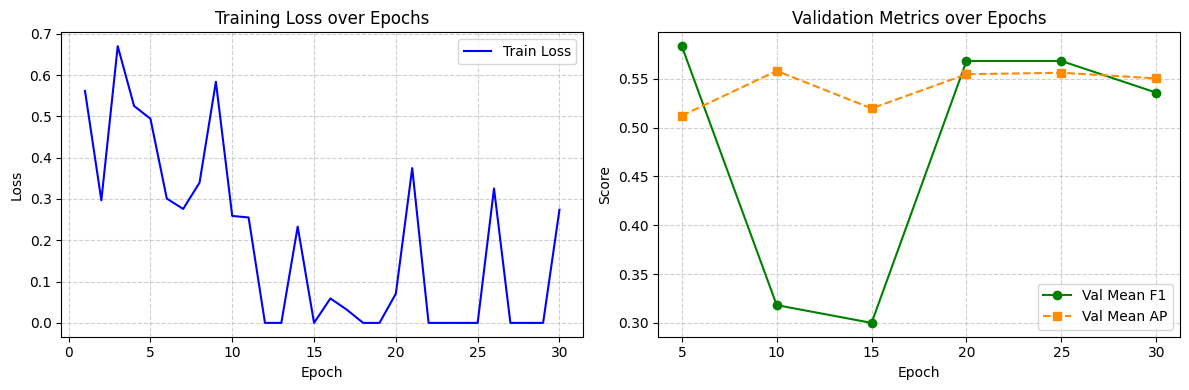

In [16]:
import matplotlib.pyplot as plt
import numpy as np

EPOCHS = 30 # Reduced for minibatch speed

best_val_ap = -1
best_state = None

history = {
    "train_loss": [],
    "val_mean_ap": [],
    "val_mean_f1": []
}

valid_train_edge_types = [et for et in TASK_EDGE_TYPES if et in train_data.edge_types and hasattr(train_data[et], 'edge_label_index')]
valid_val_edge_types = [et for et in TASK_EDGE_TYPES if et in val_data.edge_types and hasattr(val_data[et], 'edge_label_index')]

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    num_batches = 0

    iterators = [(etype, iter(loader)) for etype, loader in zip(valid_train_edge_types, train_loader)]
    active_iterators = iterators[:]

    while active_iterators:
        etype, it = active_iterators.pop(0)
        try:
            batch = next(it)
            active_iterators.append((etype, it))
        except StopIteration:
            continue

        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        loss = compute_loss(model, batch, [etype])

        if loss.item() > 0:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            num_batches += 1

    avg_loss = total_loss / max(1, num_batches)
    history["train_loss"].append(avg_loss)

    if epoch % 5 == 0:
        val_result = evaluate_auc_ap(model, val_loader, valid_val_edge_types, DEVICE)
        if not val_result: continue

        mean_val_ap = np.nanmean([v["AP"] for v in val_result.values()])
        mean_val_f1 = np.nanmean([v["F1"] for v in val_result.values()])

        if mean_val_ap > best_val_ap:
            best_val_ap = mean_val_ap
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        print(f"Epoch {epoch:03d} | Loss {avg_loss:.4f} | Val mean AP {mean_val_ap:.4f} | Val mean F1 {mean_val_f1:.4f}")
        for etype, metrics in val_result.items():
            print(f"  {etype}: AUC={metrics['AUC']:.4f}, AP={metrics['AP']:.4f}, F1={metrics['F1']:.4f}")

        history["val_mean_ap"].append((epoch, mean_val_ap))
        history["val_mean_f1"].append((epoch, mean_val_f1))

if best_state is not None:
    model.load_state_dict(best_state)

print("Training finished.")

# -------- Plotting Training Progress --------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), history["train_loss"], label="Train Loss", color='blue')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
if history["val_mean_ap"]:
    val_epochs, val_aps = zip(*history["val_mean_ap"])
    val_epochs, val_f1s = zip(*history["val_mean_f1"])

    plt.plot(val_epochs, val_f1s, label="Val Mean F1", marker='o', color='green', linestyle='-')
    plt.plot(val_epochs, val_aps, label="Val Mean AP", marker='s', color='darkorange', linestyle='--')
    plt.title("Validation Metrics over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

plt.tight_layout()
plt.show()

In [18]:
@torch.no_grad()
def recall_at_k(model, batch_data, edge_type, k=3):
    model.eval()

    # 중요: test_data도 model과 같은 device로 이동
    batch_data = batch_data.to(DEVICE)

    # edge type이 존재하는지 확인
    if edge_type not in batch_data.edge_types:
        print(f"[Warning] Edge type not found: {edge_type}")
        return np.nan

    src_type, rel_type, dst_type = edge_type

    # edge_label_index / edge_label이 있는지 확인
    if not hasattr(batch_data[edge_type], "edge_label_index"):
        print(f"[Warning] edge_label_index not found for {edge_type}")
        return np.nan

    if not hasattr(batch_data[edge_type], "edge_label"):
        print(f"[Warning] edge_label not found for {edge_type}")
        return np.nan

    z_dict = model(batch_data)

    edge_label_index = batch_data[edge_type].edge_label_index
    edge_label = batch_data[edge_type].edge_label

    # positive edge만 사용
    pos_mask = edge_label > 0.5
    pos_edge_index = edge_label_index[:, pos_mask]

    if pos_edge_index.size(1) == 0:
        print(f"[Warning] No positive edges for {edge_type}")
        return np.nan

    dst_all = z_dict[dst_type]
    hits = 0

    for i in range(pos_edge_index.size(1)):
        src_idx = pos_edge_index[0, i].long()
        true_dst_idx = pos_edge_index[1, i].long()

        src_vec = z_dict[src_type][src_idx]

        # dot product score: 모든 dst 후보와 src 하나의 유사도 계산
        scores = torch.matmul(dst_all, src_vec)

        topk = torch.topk(
            scores,
            k=min(k, dst_all.size(0))
        ).indices

        if (topk == true_dst_idx).any():
            hits += 1

    return hits / pos_edge_index.size(1)

In [28]:
@torch.no_grad()
def rank_metabolites_for_disease(
    model,
    full_data,
    disease_id="ALOPECIA",
    top_k=100,
):
    model.eval()

    full_data = full_data.to(DEVICE)
    z_dict = model(full_data)

    if disease_id not in disease2idx:
        raise ValueError(
            f"{disease_id} not found in disease2idx. "
            f"Available diseases: {list(disease2idx.keys())}"
        )

    disease_idx = disease2idx[disease_id]
    disease_vec = z_dict["disease"][disease_idx]

    metabolite_mat = z_dict["metabolite"]

    # Disease embedding과 모든 metabolite embedding의 dot product
    logits = torch.matmul(metabolite_mat, disease_vec)
    probs = torch.sigmoid(logits)

    top = torch.topk(probs, k=min(top_k, probs.size(0)))

    rows = []
    for rank, (idx, score) in enumerate(
        zip(top.indices.cpu().tolist(), top.values.cpu().tolist()),
        start=1
    ):
        rows.append({
            "rank": rank,
            "metabolite_name": idx2met[idx],
            "disease_id": disease_id,
            "metabolite_gnn_score": float(score),
        })

    return pd.DataFrame(rows)


metabolite_rank_df = rank_metabolites_for_disease(
    model,
    data,
    disease_id="ALOPECIA",
    top_k=100,
)

display(metabolite_rank_df)

,rank,metabolite_name,disease_id,metabolite_gnn_score
0,1,dimethylallyl pyrophosphate,ALOPECIA,0.999884
1,2,mevalonic acid,ALOPECIA,0.999393
2,3,geraniol,ALOPECIA,0.999327
3,4,farnesol,ALOPECIA,0.999123
4,5,"2,3-oxidosqualene",ALOPECIA,0.992679
5,6,acetoacetyl-CoA,ALOPECIA,0.991131
6,7,3-hydroxy-3-methylglutaryl-CoA,ALOPECIA,0.991006
7,8,fecosterol,ALOPECIA,0.871776
8,9,stigmasterol,ALOPECIA,0.639452
9,10,episterol,ALOPECIA,0.589866


In [30]:
def build_path_explanation():
    rows = []

    for _, gm in gene_metabolite_edges.iterrows():
        gene = gm["gene_id"]
        met = gm["metabolite_name"]

        sim_hits = metabolite_drug_edges[
            metabolite_drug_edges["metabolite_name"] == met
        ]

        for _, sim in sim_hits.iterrows():
            drug = sim["drug_name"]
            tanimoto = sim["tanimoto"]

            dt_hits = drug_target_edges[
                drug_target_edges["drug_name"] == drug
            ]

            for _, dt in dt_hits.iterrows():
                target = dt["target_id"]
                dt_conf = dt["confidence"]

                td_hits = target_disease_edges[
                    target_disease_edges["target_id"] == target
                ]

                for _, td in td_hits.iterrows():
                    disease = td["disease_id"]
                    disease_score = td["association_score"]

                    path_score = tanimoto * dt_conf * disease_score

                    rows.append({
                        "gene_id": gene,
                        "metabolite": met,
                        "similar_drug": drug,
                        "target": target,
                        "disease": disease,
                        "tanimoto": tanimoto,
                        "drug_target_confidence": dt_conf,
                        "target_disease_score": disease_score,
                        "path_score": path_score,
                    })

    return pd.DataFrame(rows)


path_df = build_path_explanation()

display(
    path_df.sort_values("path_score", ascending=False).head(30)
)

,gene_id,metabolite,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
40,ERG6,stigmasterol,epristeride,SRD5A2,ALOPECIA,0.280488,0.80,1.0,0.224390
41,ERG6,stigmasterol,clascoterone,AR,ALOPECIA,0.235294,0.80,0.9,0.169412
35,ERG2,episterol,epristeride,SRD5A2,ALOPECIA,0.159091,0.80,1.0,0.127273
42,ERG6,stigmasterol,spironolactone,AR,ALOPECIA,0.179775,0.70,0.9,0.113258
31,ERG6,fecosterol,epristeride,SRD5A2,ALOPECIA,0.133333,0.80,1.0,0.106667
43,ERG6,stigmasterol,cyproterone acetate,AR,ALOPECIA,0.129032,0.85,0.9,0.098710
30,ERG6,fecosterol,clascoterone,AR,ALOPECIA,0.133333,0.80,0.9,0.096000
36,ERG2,episterol,cyproterone acetate,AR,ALOPECIA,0.120879,0.85,0.9,0.092473
1,ERG10,acetoacetyl-CoA,enzalutamide,AR,ALOPECIA,0.106061,0.95,0.9,0.090682
38,ERG2,episterol,flutamide,AR,ALOPECIA,0.115385,0.85,0.9,0.088269


In [31]:
# -----------------------------
# Metabolite-level final ranking
# GNN score + gene-origin path score
# -----------------------------

# 혹시 path_df에서 column 이름이 "metabolite"로 되어 있으면 "metabolite_name"으로 통일
if "metabolite_name" not in path_df.columns and "metabolite" in path_df.columns:
    path_df = path_df.rename(columns={"metabolite": "metabolite_name"})

# ALOPECIA path만 사용
alopecia_path_df = path_df[path_df["disease"] == "ALOPECIA"].copy()

# metabolite별 최고 path score
metabolite_path_score = (
    alopecia_path_df
    .groupby("metabolite_name")
    .agg(
        path_score=("path_score", "max"),
        num_supporting_genes=("gene_id", "nunique"),
        num_paths=("path_score", "count"),
    )
    .reset_index()
)

# 0~1 scaling
if len(metabolite_path_score) > 0:
    max_path = metabolite_path_score["path_score"].max()
    if max_path > 0:
        metabolite_path_score["path_score_scaled"] = (
            metabolite_path_score["path_score"] / max_path
        )
    else:
        metabolite_path_score["path_score_scaled"] = 0.0
else:
    metabolite_path_score["path_score_scaled"] = 0.0


# metabolite_rank_df와 path score merge
final_metabolite_rank_df = metabolite_rank_df.merge(
    metabolite_path_score[
        [
            "metabolite_name",
            "path_score",
            "path_score_scaled",
            "num_supporting_genes",
            "num_paths",
        ]
    ],
    on="metabolite_name",
    how="left"
)

# path가 없는 metabolite는 0점 처리
final_metabolite_rank_df["path_score"] = (
    final_metabolite_rank_df["path_score"].fillna(0.0)
)

final_metabolite_rank_df["path_score_scaled"] = (
    final_metabolite_rank_df["path_score_scaled"].fillna(0.0)
)

final_metabolite_rank_df["num_supporting_genes"] = (
    final_metabolite_rank_df["num_supporting_genes"].fillna(0).astype(int)
)

final_metabolite_rank_df["num_paths"] = (
    final_metabolite_rank_df["num_paths"].fillna(0).astype(int)
)

# 최종 score
final_metabolite_rank_df["final_score"] = (
    0.5 * final_metabolite_rank_df["metabolite_gnn_score"]
    + 0.5 * final_metabolite_rank_df["path_score_scaled"]
)

# final_score 기준 정렬
final_metabolite_rank_df = final_metabolite_rank_df.sort_values(
    "final_score",
    ascending=False
).reset_index(drop=True)

final_metabolite_rank_df["final_rank"] = np.arange(
    1,
    len(final_metabolite_rank_df) + 1
)

display(final_metabolite_rank_df[
    [
        "final_rank",
        "metabolite_name",
        "metabolite_gnn_score",
        "path_score",
        "path_score_scaled",
        "num_supporting_genes",
        "num_paths",
        "final_score",
    ]
])

,final_rank,metabolite_name,metabolite_gnn_score,path_score,path_score_scaled,num_supporting_genes,num_paths,final_score
0,1,stigmasterol,0.639452,0.224390,1.000000,1,5,0.819726
1,2,acetoacetyl-CoA,0.991131,0.090682,0.404125,1,5,0.697628
2,3,mevalonic acid,0.999393,0.086154,0.383946,2,10,0.691670
3,4,3-hydroxy-3-methylglutaryl-CoA,0.991006,0.087372,0.389376,1,5,0.690191
4,5,fecosterol,0.871776,0.106667,0.475362,1,5,0.673569
5,6,"2,3-oxidosqualene",0.992679,0.070000,0.311957,1,5,0.652318
6,7,geraniol,0.999327,0.066462,0.296187,1,5,0.647757
7,8,farnesol,0.999123,0.065455,0.291700,1,5,0.645411
8,9,dimethylallyl pyrophosphate,0.999884,0.061714,0.275031,1,5,0.637458
9,10,episterol,0.589866,0.127273,0.567194,1,5,0.578530


In [32]:
# -----------------------------
# Final Metabolite Ranking
# relevance = metabolite_gnn_score + gene-origin path_score
# -----------------------------

# path_df의 metabolite column 이름 통일
if "metabolite_name" not in path_df.columns and "metabolite" in path_df.columns:
    path_df = path_df.rename(columns={"metabolite": "metabolite_name"})

# ALOPECIA로 이어지는 path만 사용
alopecia_path_df = path_df[path_df["disease"] == "ALOPECIA"].copy()

# metabolite별 path score 계산
# gene → metabolite → drug → target → ALOPECIA 경로를 metabolite 단위로 aggregate
metabolite_path_score = (
    alopecia_path_df
    .groupby("metabolite_name")
    .agg(
        path_score=("path_score", "max"),
        num_supporting_genes=("gene_id", "nunique"),
        num_paths=("path_score", "count"),
    )
    .reset_index()
)

# path_score 0~1 scaling
if len(metabolite_path_score) > 0:
    max_path = metabolite_path_score["path_score"].max()

    if max_path > 0:
        metabolite_path_score["path_score_scaled"] = (
            metabolite_path_score["path_score"] / max_path
        )
    else:
        metabolite_path_score["path_score_scaled"] = 0.0
else:
    metabolite_path_score = pd.DataFrame(
        columns=[
            "metabolite_name",
            "path_score",
            "num_supporting_genes",
            "num_paths",
            "path_score_scaled",
        ]
    )

# metabolite GNN ranking과 path score merge
final_metabolite_rank_df = metabolite_rank_df.merge(
    metabolite_path_score[
        [
            "metabolite_name",
            "path_score",
            "path_score_scaled",
            "num_supporting_genes",
            "num_paths",
        ]
    ],
    on="metabolite_name",
    how="left"
)

# path가 없는 metabolite는 0으로 처리
final_metabolite_rank_df["path_score"] = (
    final_metabolite_rank_df["path_score"].fillna(0.0)
)

final_metabolite_rank_df["path_score_scaled"] = (
    final_metabolite_rank_df["path_score_scaled"].fillna(0.0)
)

final_metabolite_rank_df["num_supporting_genes"] = (
    final_metabolite_rank_df["num_supporting_genes"].fillna(0).astype(int)
)

final_metabolite_rank_df["num_paths"] = (
    final_metabolite_rank_df["num_paths"].fillna(0).astype(int)
)

# 최종 relevance score
final_metabolite_rank_df["final_score"] = (
    0.5 * final_metabolite_rank_df["metabolite_gnn_score"]
    + 0.5 * final_metabolite_rank_df["path_score_scaled"]
)

# final score 기준 정렬
final_metabolite_rank_df = (
    final_metabolite_rank_df
    .sort_values("final_score", ascending=False)
    .reset_index(drop=True)
)

final_metabolite_rank_df["final_rank"] = np.arange(
    1,
    len(final_metabolite_rank_df) + 1
)

display(final_metabolite_rank_df[
    [
        "final_rank",
        "metabolite_name",
        "metabolite_gnn_score",
        "path_score",
        "path_score_scaled",
        "num_supporting_genes",
        "num_paths",
        "final_score",
    ]
])

,final_rank,metabolite_name,metabolite_gnn_score,path_score,path_score_scaled,num_supporting_genes,num_paths,final_score
0,1,stigmasterol,0.639452,0.224390,1.000000,1,5,0.819726
1,2,acetoacetyl-CoA,0.991131,0.090682,0.404125,1,5,0.697628
2,3,mevalonic acid,0.999393,0.086154,0.383946,2,10,0.691670
3,4,3-hydroxy-3-methylglutaryl-CoA,0.991006,0.087372,0.389376,1,5,0.690191
4,5,fecosterol,0.871776,0.106667,0.475362,1,5,0.673569
5,6,"2,3-oxidosqualene",0.992679,0.070000,0.311957,1,5,0.652318
6,7,geraniol,0.999327,0.066462,0.296187,1,5,0.647757
7,8,farnesol,0.999123,0.065455,0.291700,1,5,0.645411
8,9,dimethylallyl pyrophosphate,0.999884,0.061714,0.275031,1,5,0.637458
9,10,episterol,0.589866,0.127273,0.567194,1,5,0.578530


In [34]:
# -----------------------------
# MMR Re-ranking using Drug-Similarity Profile
# candidate: metabolite
# relevance: final_score
# diversity penalty: drug-profile similarity
# -----------------------------

def build_drug_profile_similarity_matrix(candidates, metabolite_drug_edges):
    """
    각 metabolite를 'known drugs에 대한 Tanimoto similarity vector'로 표현.
    두 metabolite의 redundancy는 이 drug-profile vector의 cosine similarity로 계산.
    """

    candidate_mets = candidates["metabolite_name"].tolist()

    pivot = (
        metabolite_drug_edges
        .pivot_table(
            index="metabolite_name",
            columns="drug_name",
            values="tanimoto",
            aggfunc="max",
            fill_value=0.0,
        )
    )

    # candidate 순서에 맞춰 row 재정렬
    pivot = pivot.reindex(candidate_mets).fillna(0.0)

    profile = pivot.to_numpy(dtype=float)

    # cosine similarity 계산
    norms = np.linalg.norm(profile, axis=1, keepdims=True)

    # zero vector 방지
    profile_norm = np.divide(
        profile,
        norms,
        out=np.zeros_like(profile),
        where=(norms != 0)
    )

    sim_matrix = profile_norm @ profile_norm.T

    return sim_matrix


def mmr_rerank_metabolites_by_drug_similarity(
    rank_df,
    metabolite_drug_edges,
    score_col="final_score",
    top_k=10,
    candidate_k=100,
    lambda_mmr=0.7,
):
    """
    MMR re-ranking for new-drug → metabolite discovery.

    relevance:
        final_score

    redundancy penalty:
        similarity between metabolite drug-similarity profiles

    MMR:
        lambda * relevance - (1 - lambda) * max drug-profile similarity
    """

    candidates = (
        rank_df
        .sort_values(score_col, ascending=False)
        .head(min(candidate_k, len(rank_df)))
        .copy()
        .reset_index(drop=True)
    )

    if len(candidates) == 0:
        return candidates

    # drug similarity profile 기반 candidate-candidate similarity
    sim_matrix = build_drug_profile_similarity_matrix(
        candidates,
        metabolite_drug_edges
    )

    # relevance 0~1 scaling
    relevance = candidates[score_col].astype(float).to_numpy()

    if relevance.max() > relevance.min():
        relevance = (
            relevance - relevance.min()
        ) / (
            relevance.max() - relevance.min()
        )
    else:
        relevance = np.ones_like(relevance)

    selected = []
    remaining = list(range(len(candidates)))
    selected_mmr_scores = []

    while remaining and len(selected) < top_k:
        if len(selected) == 0:
            best = max(remaining, key=lambda i: relevance[i])
            best_mmr_score = relevance[best]
        else:
            def compute_mmr_score(i):
                max_sim_to_selected = max(
                    sim_matrix[i, j]
                    for j in selected
                )

                return (
                    lambda_mmr * relevance[i]
                    - (1.0 - lambda_mmr) * max_sim_to_selected
                )

            best = max(remaining, key=compute_mmr_score)
            best_mmr_score = compute_mmr_score(best)

        selected.append(best)
        selected_mmr_scores.append(best_mmr_score)
        remaining.remove(best)

    mmr_df = candidates.iloc[selected].copy().reset_index(drop=True)
    mmr_df["mmr_rank"] = np.arange(1, len(mmr_df) + 1)
    mmr_df["mmr_score"] = selected_mmr_scores

    cols = [
        "mmr_rank",
        "metabolite_name",
        score_col,
        "candidate_score_scaled",
        "path_score",
        "path_score_scaled",
        "num_supporting_genes",
        "num_paths",
        "mmr_score",
    ]

    cols = [c for c in cols if c in mmr_df.columns]
    other_cols = [c for c in mmr_df.columns if c not in cols]

    return mmr_df[cols + other_cols]

In [35]:
# -----------------------------
# Run MMR Re-ranking
# -----------------------------

mmr_metabolite_rank_df = mmr_rerank_metabolites_by_drug_similarity(
    rank_df=final_metabolite_rank_df,
    metabolite_drug_edges=metabolite_drug_edges,
    score_col="final_score",
    top_k=10,
    candidate_k=100,
    lambda_mmr=0.7,
)

display_cols = [
    "mmr_rank",
    "metabolite_name",
    "metabolite_gnn_score",
    "path_score",
    "path_score_scaled",
    "num_supporting_genes",
    "num_paths",
    "final_score",
    "mmr_score",
]

display_cols = [c for c in display_cols if c in mmr_metabolite_rank_df.columns]

display(mmr_metabolite_rank_df[display_cols])

,mmr_rank,metabolite_name,metabolite_gnn_score,path_score,path_score_scaled,num_supporting_genes,num_paths,final_score,mmr_score
0,1,stigmasterol,0.639452,0.224390,1.000000,1,5,0.819726,1.000000
1,2,acetoacetyl-CoA,0.991131,0.090682,0.404125,1,5,0.697628,0.243385
2,3,mevalonic acid,0.999393,0.086154,0.383946,2,10,0.691670,0.128285
3,4,3-hydroxy-3-methylglutaryl-CoA,0.991006,0.087372,0.389376,1,5,0.690191,0.024415
4,5,"2,3-oxidosqualene",0.992679,0.070000,0.311957,1,5,0.652318,0.011379
5,6,fecosterol,0.871776,0.106667,0.475362,1,5,0.673569,-0.016326
6,7,geraniol,0.999327,0.066462,0.296187,1,5,0.647757,-0.046105
7,8,farnesol,0.999123,0.065455,0.291700,1,5,0.645411,-0.105896
8,9,dimethylallyl pyrophosphate,0.999884,0.061714,0.275031,1,5,0.637458,-0.124573
9,10,episterol,0.589866,0.127273,0.567194,1,5,0.578530,-0.260213


In [36]:
  # -----------------------------
# Path explanation for MMR-selected metabolites
# -----------------------------

def show_metabolite_path_explanation(
    rank_df,
    path_df,
    top_n=5,
    disease_id="ALOPECIA",
):
    """
    MMR로 선택된 metabolite들이 어떤 path를 통해 ALOPECIA와 연결되는지 출력.
    """

    path_df = path_df.copy()

    if "metabolite_name" not in path_df.columns and "metabolite" in path_df.columns:
        path_df = path_df.rename(columns={"metabolite": "metabolite_name"})

    disease_path_df = path_df[path_df["disease"] == disease_id].copy()

    for met in rank_df["metabolite_name"].head(top_n):
        print("=" * 90)
        print(f"Metabolite: {met}")

        met_paths = (
            disease_path_df[
                disease_path_df["metabolite_name"] == met
            ]
            .sort_values("path_score", ascending=False)
        )

        if len(met_paths) == 0:
            print("No interpretable path found.")
        else:
            display(met_paths[
                [
                    "gene_id",
                    "metabolite_name",
                    "similar_drug",
                    "target",
                    "disease",
                    "tanimoto",
                    "drug_target_confidence",
                    "target_disease_score",
                    "path_score",
                ]
            ].head(5))


show_metabolite_path_explanation(
    rank_df=mmr_metabolite_rank_df,
    path_df=path_df,
    top_n=5,
    disease_id="ALOPECIA",
)

Metabolite: stigmasterol


,gene_id,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
40,ERG6,stigmasterol,epristeride,SRD5A2,ALOPECIA,0.280488,0.80,1.0,0.224390
41,ERG6,stigmasterol,clascoterone,AR,ALOPECIA,0.235294,0.80,0.9,0.169412
42,ERG6,stigmasterol,spironolactone,AR,ALOPECIA,0.179775,0.70,0.9,0.113258
43,ERG6,stigmasterol,cyproterone acetate,AR,ALOPECIA,0.129032,0.85,0.9,0.098710
44,ERG6,stigmasterol,simvastatin,HMGCR,ALOPECIA,0.111111,0.80,0.1,0.008889


Metabolite: acetoacetyl-CoA


,gene_id,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
1,ERG10,acetoacetyl-CoA,enzalutamide,AR,ALOPECIA,0.106061,0.95,0.9,0.090682
3,ERG10,acetoacetyl-CoA,flutamide,AR,ALOPECIA,0.095652,0.85,0.9,0.073174
4,ERG10,acetoacetyl-CoA,epristeride,SRD5A2,ALOPECIA,0.084615,0.80,1.0,0.067692
0,ERG10,acetoacetyl-CoA,ketoconazole,CYP51A1,ALOPECIA,0.129496,0.70,0.3,0.027194
2,ERG10,acetoacetyl-CoA,simvastatin,HMGCR,ALOPECIA,0.106061,0.80,0.1,0.008485


Metabolite: mevalonic acid


,gene_id,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
10,HMG1,mevalonic acid,epristeride,SRD5A2,ALOPECIA,0.107692,0.80,1.0,0.086154
15,HMG2,mevalonic acid,epristeride,SRD5A2,ALOPECIA,0.107692,0.80,1.0,0.086154
17,HMG2,mevalonic acid,flutamide,AR,ALOPECIA,0.096154,0.85,0.9,0.073558
12,HMG1,mevalonic acid,flutamide,AR,ALOPECIA,0.096154,0.85,0.9,0.073558
18,HMG2,mevalonic acid,clascoterone,AR,ALOPECIA,0.090909,0.80,0.9,0.065455


Metabolite: 3-hydroxy-3-methylglutaryl-CoA


,gene_id,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
6,ERG13,3-hydroxy-3-methylglutaryl-CoA,enzalutamide,AR,ALOPECIA,0.102190,0.95,0.9,0.087372
9,ERG13,3-hydroxy-3-methylglutaryl-CoA,epristeride,SRD5A2,ALOPECIA,0.089552,0.80,1.0,0.071642
8,ERG13,3-hydroxy-3-methylglutaryl-CoA,flutamide,AR,ALOPECIA,0.091667,0.85,0.9,0.070125
5,ERG13,3-hydroxy-3-methylglutaryl-CoA,ketoconazole,CYP51A1,ALOPECIA,0.117241,0.70,0.3,0.024621
7,ERG13,3-hydroxy-3-methylglutaryl-CoA,simvastatin,HMGCR,ALOPECIA,0.102190,0.80,0.1,0.008175


Metabolite: 2,3-oxidosqualene


,gene_id,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
25,ERG1,"2,3-oxidosqualene",spironolactone,AR,ALOPECIA,0.111111,0.70,0.9,0.070000
26,ERG1,"2,3-oxidosqualene",clascoterone,AR,ALOPECIA,0.095890,0.80,0.9,0.069041
29,ERG1,"2,3-oxidosqualene",cyproterone acetate,AR,ALOPECIA,0.081081,0.85,0.9,0.062027
27,ERG1,"2,3-oxidosqualene",ketoconazole,CYP51A1,ALOPECIA,0.090909,0.70,0.3,0.019091
28,ERG1,"2,3-oxidosqualene",simvastatin,HMGCR,ALOPECIA,0.089744,0.80,0.1,0.007179


In [37]:
# -----------------------------
# Inductive inference: add new drug node from SMILES
# -----------------------------

@torch.no_grad()
def infer_new_drug(
    model,
    base_data,
    new_drug_smiles,
    target_edges=None,
    metabolite_edges=None,
):
    """
    새로운 drug SMILES를 graph에 임시 node로 추가하고,
    HAN embedding space에서 new drug embedding을 계산한다.

    target_edges:
        새 drug가 이미 interact한다고 알고 있는 target_id list.
        모르면 None으로 둔다.

    metabolite_edges:
        새 drug와 유사하다고 알고 있는 metabolite_name list.
        모르면 None으로 둔다.
    """

    if target_edges is None:
        target_edges = []

    if metabolite_edges is None:
        metabolite_edges = []

    model.eval()

    # 1. SMILES → Morgan fingerprint
    fp = smiles_to_fp(new_drug_smiles)

    if fp is None:
        raise ValueError(f"Invalid SMILES string: {new_drug_smiles}")

    new_x = fp_to_tensor(fp).unsqueeze(0).to(DEVICE)

    # 기존 drug feature dimension과 맞는지 확인
    expected_dim = base_data["drug"].x.size(1)

    if new_x.size(1) != expected_dim:
        raise ValueError(
            f"Fingerprint dimension mismatch: new_x={new_x.size(1)}, "
            f"expected={expected_dim}"
        )

    # 2. 기존 graph 복사 후 new drug node 추가
    infer_data = base_data.clone().to(DEVICE)

    new_drug_idx = infer_data["drug"].x.size(0)

    infer_data["drug"].x = torch.cat(
        [infer_data["drug"].x, new_x],
        dim=0
    )

    infer_data["drug"].num_nodes = infer_data["drug"].x.size(0)

    # 3. optional drug → target edge 추가
    new_dt_src = []
    new_dt_dst = []

    for tgt in target_edges:
        if tgt in target2idx:
            new_dt_src.append(new_drug_idx)
            new_dt_dst.append(target2idx[tgt])

    if len(new_dt_src) > 0:
        new_edge = torch.tensor(
            [new_dt_src, new_dt_dst],
            dtype=torch.long,
            device=DEVICE,
        )

        old_edge = infer_data["drug", "inhibits", "target"].edge_index
        infer_data["drug", "inhibits", "target"].edge_index = torch.cat(
            [old_edge, new_edge],
            dim=1,
        )

        rev_new_edge = torch.tensor(
            [new_dt_dst, new_dt_src],
            dtype=torch.long,
            device=DEVICE,
        )

        old_rev_edge = infer_data["target", "rev_inhibits", "drug"].edge_index
        infer_data["target", "rev_inhibits", "drug"].edge_index = torch.cat(
            [old_rev_edge, rev_new_edge],
            dim=1,
        )

    # 4. optional metabolite → drug edge 추가
    new_md_src = []
    new_md_dst = []

    for met in metabolite_edges:
        if met in met2idx:
            new_md_src.append(met2idx[met])
            new_md_dst.append(new_drug_idx)

    if len(new_md_src) > 0:
        new_edge = torch.tensor(
            [new_md_src, new_md_dst],
            dtype=torch.long,
            device=DEVICE,
        )

        old_edge = infer_data["metabolite", "similar_to", "drug"].edge_index
        infer_data["metabolite", "similar_to", "drug"].edge_index = torch.cat(
            [old_edge, new_edge],
            dim=1,
        )

        rev_new_edge = torch.tensor(
            [new_md_dst, new_md_src],
            dtype=torch.long,
            device=DEVICE,
        )

        old_rev_edge = infer_data["drug", "rev_similar_to", "metabolite"].edge_index
        infer_data["drug", "rev_similar_to", "metabolite"].edge_index = torch.cat(
            [old_rev_edge, rev_new_edge],
            dim=1,
        )

    # 5. HAN forward
    z_dict = model(infer_data)

    new_drug_emb = z_dict["drug"][new_drug_idx]

    print("New drug embedding shape:", new_drug_emb.shape)
    print("New drug node index:", new_drug_idx)

    return {
        "infer_data": infer_data,
        "z_dict": z_dict,
        "new_drug_idx": new_drug_idx,
        "new_drug_emb": new_drug_emb,
    }

In [38]:
# -----------------------------
# Rank metabolites for a new drug
# -----------------------------

@torch.no_grad()
def rank_metabolites_for_new_drug(
    model,
    base_data,
    new_drug_smiles,
    new_drug_name="NEW_DRUG",
    target_edges=None,
    metabolite_edges=None,
    top_k=100,
):
    """
    새로운 drug SMILES를 넣었을 때,
    모든 metabolite 후보에 대해 new_drug_score를 계산한다.
    """

    result = infer_new_drug(
        model=model,
        base_data=base_data,
        new_drug_smiles=new_drug_smiles,
        target_edges=target_edges,
        metabolite_edges=metabolite_edges,
    )

    z_dict = result["z_dict"]
    new_drug_emb = result["new_drug_emb"]

    metabolite_emb = z_dict["metabolite"]

    logits = torch.matmul(metabolite_emb, new_drug_emb)
    probs = torch.sigmoid(logits)

    top = torch.topk(
        probs,
        k=min(top_k, probs.size(0))
    )

    rows = []

    for rank, (idx, score) in enumerate(
        zip(top.indices.cpu().tolist(), top.values.cpu().tolist()),
        start=1,
    ):
        rows.append({
            "rank": rank,
            "metabolite_name": idx2met[idx],
            "query_drug": new_drug_name,
            "new_drug_score": float(score),
        })

    return pd.DataFrame(rows)

In [39]:
# -----------------------------
# Final ranking for new drug → metabolite
# -----------------------------

def build_final_new_drug_metabolite_ranking(
    metabolite_candidate_df,
    path_df,
    disease_id="ALOPECIA",
    w_new_drug=0.7,
    w_path=0.3,
):
    """
    final_score =
        w_new_drug * new_drug_score_scaled
        + w_path * path_score_scaled
    """

    path_df = path_df.copy()

    if "metabolite_name" not in path_df.columns and "metabolite" in path_df.columns:
        path_df = path_df.rename(columns={"metabolite": "metabolite_name"})

    disease_path_df = path_df[path_df["disease"] == disease_id].copy()

    metabolite_path_score = (
        disease_path_df
        .groupby("metabolite_name")
        .agg(
            path_score=("path_score", "max"),
            num_supporting_genes=("gene_id", "nunique"),
            num_paths=("path_score", "count"),
        )
        .reset_index()
    )

    if len(metabolite_path_score) > 0:
        max_path = metabolite_path_score["path_score"].max()

        if max_path > 0:
            metabolite_path_score["path_score_scaled"] = (
                metabolite_path_score["path_score"] / max_path
            )
        else:
            metabolite_path_score["path_score_scaled"] = 0.0
    else:
        metabolite_path_score = pd.DataFrame(
            columns=[
                "metabolite_name",
                "path_score",
                "num_supporting_genes",
                "num_paths",
                "path_score_scaled",
            ]
        )

    final_df = metabolite_candidate_df.merge(
        metabolite_path_score[
            [
                "metabolite_name",
                "path_score",
                "path_score_scaled",
                "num_supporting_genes",
                "num_paths",
            ]
        ],
        on="metabolite_name",
        how="left",
    )

    final_df["path_score"] = final_df["path_score"].fillna(0.0)
    final_df["path_score_scaled"] = final_df["path_score_scaled"].fillna(0.0)

    final_df["num_supporting_genes"] = (
        final_df["num_supporting_genes"].fillna(0).astype(int)
    )

    final_df["num_paths"] = (
        final_df["num_paths"].fillna(0).astype(int)
    )

    score = final_df["new_drug_score"].astype(float)

    if score.max() > score.min():
        final_df["new_drug_score_scaled"] = (
            (score - score.min()) / (score.max() - score.min())
        )
    else:
        final_df["new_drug_score_scaled"] = 1.0

    final_df["final_score"] = (
        w_new_drug * final_df["new_drug_score_scaled"]
        + w_path * final_df["path_score_scaled"]
    )

    final_df = (
        final_df
        .sort_values("final_score", ascending=False)
        .reset_index(drop=True)
    )

    final_df["final_rank"] = np.arange(1, len(final_df) + 1)

    return final_df

In [40]:
# -----------------------------
# Run full new drug → metabolite pipeline
# -----------------------------

new_drug_name = "ibuprofen"
new_drug_smiles = "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O"

# 1. New drug → metabolite candidate ranking
new_drug_metabolite_df = rank_metabolites_for_new_drug(
    model=model,
    base_data=data,
    new_drug_smiles=new_drug_smiles,
    new_drug_name=new_drug_name,
    target_edges=None,
    metabolite_edges=None,
    top_k=100,
)

print("New drug → metabolite ranking")
display(new_drug_metabolite_df.head(20))


# 2. new_drug_score + ALOPECIA path_score
final_new_drug_rank_df = build_final_new_drug_metabolite_ranking(
    metabolite_candidate_df=new_drug_metabolite_df,
    path_df=path_df,
    disease_id="ALOPECIA",
    w_new_drug=0.7,
    w_path=0.3,
)

print("Final new drug → metabolite ranking")
display(final_new_drug_rank_df[
    [
        "final_rank",
        "metabolite_name",
        "query_drug",
        "new_drug_score",
        "new_drug_score_scaled",
        "path_score",
        "path_score_scaled",
        "num_supporting_genes",
        "num_paths",
        "final_score",
    ]
].head(20))


# 3. MMR re-ranking
mmr_new_drug_rank_df = mmr_rerank_metabolites_by_drug_similarity(
    rank_df=final_new_drug_rank_df,
    metabolite_drug_edges=metabolite_drug_edges,
    score_col="final_score",
    top_k=10,
    candidate_k=100,
    lambda_mmr=0.7,
)

print("MMR new drug → metabolite ranking")
display(mmr_new_drug_rank_df[
    [
        "mmr_rank",
        "metabolite_name",
        "query_drug",
        "new_drug_score",
        "new_drug_score_scaled",
        "path_score",
        "path_score_scaled",
        "num_supporting_genes",
        "num_paths",
        "final_score",
        "mmr_score",
    ]
])

New drug embedding shape: torch.Size([64])
New drug node index: 11
New drug → metabolite ranking


,rank,metabolite_name,query_drug,new_drug_score
0,1,dimethylallyl pyrophosphate,ibuprofen,0.608245
1,2,mevalonic acid,ibuprofen,0.603862
2,3,geraniol,ibuprofen,0.582938
3,4,farnesol,ibuprofen,0.581622
4,5,"2,3-oxidosqualene",ibuprofen,0.575944
5,6,3-hydroxy-3-methylglutaryl-CoA,ibuprofen,0.553409
6,7,fecosterol,ibuprofen,0.537847
7,8,acetoacetyl-CoA,ibuprofen,0.530098
8,9,episterol,ibuprofen,0.513138
9,10,stigmasterol,ibuprofen,0.485751


Final new drug → metabolite ranking


,final_rank,metabolite_name,query_drug,new_drug_score,new_drug_score_scaled,path_score,path_score_scaled,num_supporting_genes,num_paths,final_score
0,1,mevalonic acid,ibuprofen,0.603862,0.964221,0.086154,0.383946,2,10,0.790138
1,2,dimethylallyl pyrophosphate,ibuprofen,0.608245,1.000000,0.061714,0.275031,1,5,0.782509
2,3,geraniol,ibuprofen,0.582938,0.793402,0.066462,0.296187,1,5,0.644238
3,4,farnesol,ibuprofen,0.581622,0.782661,0.065455,0.291700,1,5,0.635372
4,5,"2,3-oxidosqualene",ibuprofen,0.575944,0.736307,0.070000,0.311957,1,5,0.609002
5,6,3-hydroxy-3-methylglutaryl-CoA,ibuprofen,0.553409,0.552337,0.087372,0.389376,1,5,0.503449
6,7,fecosterol,ibuprofen,0.537847,0.425292,0.106667,0.475362,1,5,0.440313
7,8,acetoacetyl-CoA,ibuprofen,0.530098,0.362028,0.090682,0.404125,1,5,0.374658
8,9,episterol,ibuprofen,0.513138,0.223574,0.127273,0.567194,1,5,0.326660
9,10,stigmasterol,ibuprofen,0.485751,0.000000,0.224390,1.000000,1,5,0.300000


MMR new drug → metabolite ranking


,mmr_rank,metabolite_name,query_drug,new_drug_score,new_drug_score_scaled,path_score,path_score_scaled,num_supporting_genes,num_paths,final_score,mmr_score
0,1,mevalonic acid,ibuprofen,0.603862,0.964221,0.086154,0.383946,2,10,0.790138,1.000000
1,2,dimethylallyl pyrophosphate,ibuprofen,0.608245,1.000000,0.061714,0.275031,1,5,0.782509,0.510960
2,3,"2,3-oxidosqualene",ibuprofen,0.575944,0.736307,0.070000,0.311957,1,5,0.609002,0.199312
3,4,geraniol,ibuprofen,0.582938,0.793402,0.066462,0.296187,1,5,0.644238,0.196036
4,5,farnesol,ibuprofen,0.581622,0.782661,0.065455,0.291700,1,5,0.635372,0.178969
5,6,3-hydroxy-3-methylglutaryl-CoA,ibuprofen,0.553409,0.552337,0.087372,0.389376,1,5,0.503449,0.111585
6,7,fecosterol,ibuprofen,0.537847,0.425292,0.106667,0.475362,1,5,0.440313,-0.039979
7,8,acetoacetyl-CoA,ibuprofen,0.530098,0.362028,0.090682,0.404125,1,5,0.374658,-0.193026
8,9,episterol,ibuprofen,0.513138,0.223574,0.127273,0.567194,1,5,0.326660,-0.212828
9,10,stigmasterol,ibuprofen,0.485751,0.000000,0.224390,1.000000,1,5,0.300000,-0.292150


In [41]:
# -----------------------------
# Explain MMR-selected metabolites for new drug
# -----------------------------

show_metabolite_path_explanation(
    rank_df=mmr_new_drug_rank_df,
    path_df=path_df,
    top_n=5,
    disease_id="ALOPECIA",
)

Metabolite: mevalonic acid


,gene_id,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
10,HMG1,mevalonic acid,epristeride,SRD5A2,ALOPECIA,0.107692,0.80,1.0,0.086154
15,HMG2,mevalonic acid,epristeride,SRD5A2,ALOPECIA,0.107692,0.80,1.0,0.086154
17,HMG2,mevalonic acid,flutamide,AR,ALOPECIA,0.096154,0.85,0.9,0.073558
12,HMG1,mevalonic acid,flutamide,AR,ALOPECIA,0.096154,0.85,0.9,0.073558
18,HMG2,mevalonic acid,clascoterone,AR,ALOPECIA,0.090909,0.80,0.9,0.065455


Metabolite: dimethylallyl pyrophosphate


,gene_id,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
20,IDI1,dimethylallyl pyrophosphate,clascoterone,AR,ALOPECIA,0.085714,0.80,0.9,0.061714
24,IDI1,dimethylallyl pyrophosphate,cyproterone acetate,AR,ALOPECIA,0.070423,0.85,0.9,0.053873
23,IDI1,dimethylallyl pyrophosphate,spironolactone,AR,ALOPECIA,0.070423,0.70,0.9,0.044366
21,IDI1,dimethylallyl pyrophosphate,simvastatin,HMGCR,ALOPECIA,0.080000,0.80,0.1,0.006400
22,IDI1,dimethylallyl pyrophosphate,tamoxifen,ESR1,ALOPECIA,0.072727,0.80,0.1,0.005818


Metabolite: 2,3-oxidosqualene


,gene_id,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
25,ERG1,"2,3-oxidosqualene",spironolactone,AR,ALOPECIA,0.111111,0.70,0.9,0.070000
26,ERG1,"2,3-oxidosqualene",clascoterone,AR,ALOPECIA,0.095890,0.80,0.9,0.069041
29,ERG1,"2,3-oxidosqualene",cyproterone acetate,AR,ALOPECIA,0.081081,0.85,0.9,0.062027
27,ERG1,"2,3-oxidosqualene",ketoconazole,CYP51A1,ALOPECIA,0.090909,0.70,0.3,0.019091
28,ERG1,"2,3-oxidosqualene",simvastatin,HMGCR,ALOPECIA,0.089744,0.80,0.1,0.007179


Metabolite: geraniol


,gene_id,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
45,ERG20,geraniol,clascoterone,AR,ALOPECIA,0.092308,0.80,0.9,0.066462
46,ERG20,geraniol,spironolactone,AR,ALOPECIA,0.075758,0.70,0.9,0.047727
47,ERG20,geraniol,cyproterone acetate,AR,ALOPECIA,0.059701,0.85,0.9,0.045672
48,ERG20,geraniol,tamoxifen,ESR1,ALOPECIA,0.058824,0.80,0.1,0.004706
49,ERG20,geraniol,simvastatin,HMGCR,ALOPECIA,0.055556,0.80,0.1,0.004444


Metabolite: farnesol


,gene_id,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
50,ERG20,farnesol,clascoterone,AR,ALOPECIA,0.090909,0.80,0.9,0.065455
51,ERG20,farnesol,spironolactone,AR,ALOPECIA,0.074627,0.70,0.9,0.047015
52,ERG20,farnesol,cyproterone acetate,AR,ALOPECIA,0.058824,0.85,0.9,0.045000
53,ERG20,farnesol,tamoxifen,ESR1,ALOPECIA,0.057692,0.80,0.1,0.004615
54,ERG20,farnesol,simvastatin,HMGCR,ALOPECIA,0.054795,0.80,0.1,0.004384


In [48]:
# -----------------------------
# Collect predicted probabilities
# compatible with InductiveHANLinkPredictor.decode()
# -----------------------------

import numpy as np
import torch

@torch.no_grad()
def collect_link_prediction_probs(model, loaders, edge_types, device):
    """
    각 edge type에 대해 y_true, y_prob를 모음.

    y_true:
        1 = 실제 존재하는 positive edge
        0 = negative sampled edge

    y_prob:
        model이 해당 edge가 존재한다고 예측한 probability
    """

    model.eval()

    results = {}

    for loader, edge_type in zip(loaders, edge_types):
        y_true_list = []
        y_prob_list = []

        src_type, rel_type, dst_type = edge_type

        for batch in loader:
            batch = batch.to(device)

            if edge_type not in batch.edge_types:
                continue

            if not hasattr(batch[edge_type], "edge_label_index"):
                continue

            if not hasattr(batch[edge_type], "edge_label"):
                continue

            edge_label_index = batch[edge_type].edge_label_index
            edge_label = batch[edge_type].edge_label.float()

            z_dict = model(batch)

            # 핵심 수정 부분
            # 기존: model.decode(z_dict, edge_label_index, edge_type)
            # 수정: model.decode(z_dict, edge_label_index, src_type, dst_type)
            if hasattr(model, "decode"):
                logits = model.decode(
                    z_dict,
                    edge_label_index,
                    src_type,
                    dst_type,
                )
            else:
                src_z = z_dict[src_type][edge_label_index[0]]
                dst_z = z_dict[dst_type][edge_label_index[1]]
                logits = (src_z * dst_z).sum(dim=-1)

            probs = torch.sigmoid(logits)

            y_true_list.extend(edge_label.detach().cpu().numpy())
            y_prob_list.extend(probs.detach().cpu().numpy())

        results[edge_type] = {
            "y_true": np.array(y_true_list),
            "y_prob": np.array(y_prob_list),
        }

    return results

In [46]:
# -----------------------------
# Plot ROC and PR curves
# -----------------------------

import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
)

def plot_roc_pr_curves(pred_results, title_prefix="Validation"):
    for edge_type, result in pred_results.items():
        y_true = result["y_true"]
        y_prob = result["y_prob"]

        if len(y_true) == 0:
            print(f"[Skip] {edge_type}: no prediction results")
            continue

        if len(np.unique(y_true)) < 2:
            print(f"[Skip] {edge_type}: only one class exists")
            continue

        roc_auc = roc_auc_score(y_true, y_prob)
        ap_score = average_precision_score(y_true, y_prob)

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        precision, recall, _ = precision_recall_curve(y_true, y_prob)

        print("=" * 80)
        print(f"Edge type: {edge_type}")
        print(f"ROC-AUC : {roc_auc:.4f}")
        print(f"PR-AUC  : {ap_score:.4f}")

        # ROC curve
        plt.figure(figsize=(5, 4))
        plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{title_prefix} ROC Curve\n{edge_type[1]}")
        plt.legend()
        plt.grid(True)
        plt.show()

        # PR curve
        plt.figure(figsize=(5, 4))
        plt.plot(recall, precision, label=f"PR-AUC = {ap_score:.4f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"{title_prefix} PR Curve\n{edge_type[1]}")
        plt.legend()
        plt.grid(True)
        plt.show()

Edge type: ('metabolite', 'similar_to', 'drug')
ROC-AUC : 0.5900
PR-AUC  : 0.6161


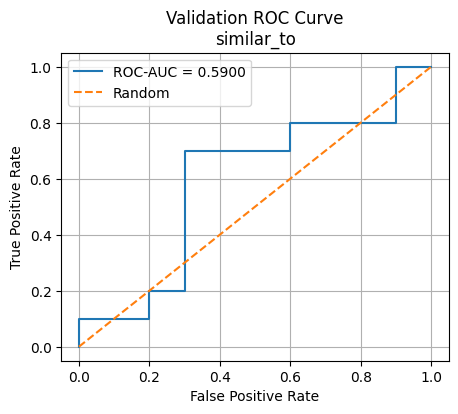

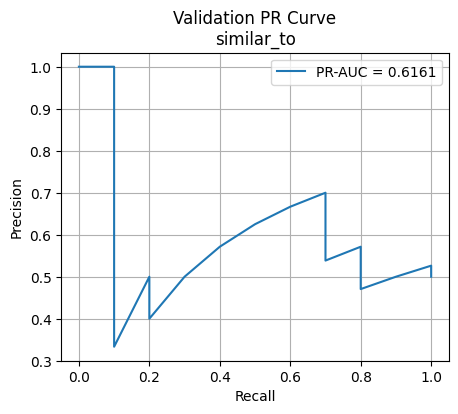

Edge type: ('drug', 'inhibits', 'target')
ROC-AUC : 0.3750
PR-AUC  : 0.5000


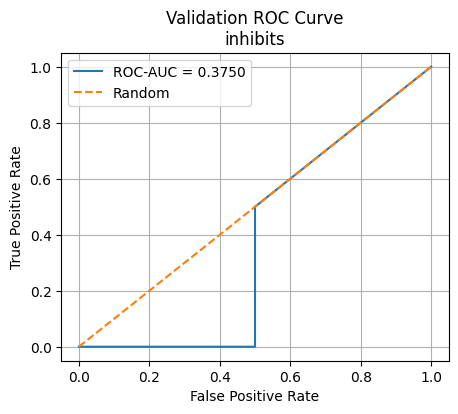

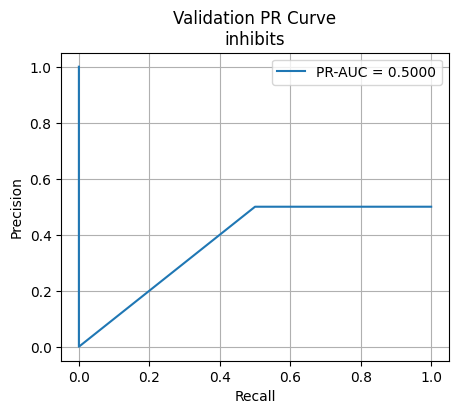

In [49]:
# -----------------------------
# Validation ROC / PR
# -----------------------------

valid_val_edge_types = [
    et for et in TASK_EDGE_TYPES
    if et in val_data.edge_types and hasattr(val_data[et], "edge_label_index")
]

val_pred_results = collect_link_prediction_probs(
    model=model,
    loaders=val_loader,
    edge_types=valid_val_edge_types,
    device=DEVICE,
)

plot_roc_pr_curves(
    pred_results=val_pred_results,
    title_prefix="Validation",
)